# MFCC-based CNN Model for Speech Emotion Recognition

This notebook implements a CNN model for speech emotion recognition using the EmotionAlly dataset. The model aims to achieve high accuracy using MFCC features combined with prosodic features.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Loading and Preprocessing

In [2]:
# --- Load and preprocess RAVDESS for training ---
def load_ravdess_data(data_path):
    """Load the RAVDESS dataset from the specified path."""
    from pathlib import Path
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {data_path}")
    data = []
    # Map RAVDESS emotion indices to 7-class system (match EmotionAlly)
    emotion_map = {
        1: ('neutral', 4),
        2: ('calm', 4),  # Map 'calm' to 'neutral'
        3: ('happy', 3),
        4: ('sad', 5),
        5: ('angry', 0),
        6: ('fearful', 2),
        7: ('disgust', 1),
        8: ('surprised', 6)
    }
    for actor_folder in data_path.iterdir():
        if actor_folder.is_dir():
            for audio_file in actor_folder.glob("*.wav"):
                parts = audio_file.stem.split('-')
                if len(parts) >= 3:
                    emotion_id = int(parts[2])
                    if emotion_id in emotion_map:
                        emotion_name, emotion_idx = emotion_map[emotion_id]
                        # Only keep 7-class mapping
                        if emotion_name in ['angry','disgust','fearful','happy','neutral','sad','surprised']:
                            data.append({
                                'path': str(audio_file),
                                'emotion': emotion_idx,
                                'emotion_name': emotion_name
                            })
    return pd.DataFrame(data)

def load_emotionally_data(data_path):
    """
    Load the EmotionAlly dataset from the specified path.
    """
    from pathlib import Path
    
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {data_path}")
    
    # Initialize lists for data collection
    data = []
    
    # Map folder names to standardized emotion labels and indices
    emotion_map = {
        'Angry': ('angry', 0),
        'Disgust': ('disgust', 1), 
        'Fear': ('fear', 2),
        'Happy': ('happy', 3),
        'Neutral': ('neutral', 4),
        'Sad': ('sad', 5),
        'Surprise': ('surprise', 6)
    }
    
    # Walk through emotion directories
    for emotion_folder in data_path.iterdir():
        if emotion_folder.is_dir() and emotion_folder.name in emotion_map:
            emotion_name, emotion_idx = emotion_map[emotion_folder.name]
            
            # Get all .wav files in this emotion folder
            for audio_file in emotion_folder.glob("*.wav"):
                data.append({
                    'path': str(audio_file),
                    'emotion': emotion_idx,
                    'emotion_name': emotion_name
                })
    
    return pd.DataFrame(data)

# Import configuration for proper path handling
from config import EMOTIONALLY_DIR

# Set RAVDESS directory path (fix double 'data' directory issue)
RAVDESS_DIR = os.path.join(os.path.dirname(EMOTIONALLY_DIR), 'ravdess_actors')
print(f"Using RAVDESS dataset path: {RAVDESS_DIR}")

# Load RAVDESS data
ravdess_df = load_ravdess_data(RAVDESS_DIR)
print(f"RAVDESS samples (7-class): {len(ravdess_df)}")
print(ravdess_df['emotion_name'].value_counts())

# Load EmotionAlly for external test set
emotionally_df = load_emotionally_data(EMOTIONALLY_DIR)
print(f"EmotionAlly samples: {len(emotionally_df)}")
print(emotionally_df['emotion_name'].value_counts())

Using RAVDESS dataset path: c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\data\ravdess_actors
RAVDESS samples (7-class): 1248
emotion_name
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64
EmotionAlly samples: 315
emotion_name
angry       45
disgust     45
fear        45
happy       45
neutral     45
sad         45
surprise    45
Name: count, dtype: int64


In [ ]:
# --- Improved data splitting: Use both datasets for training ---
print("Extracting features for RAVDESS and EmotionAlly...")

def extract_prosodic_features(file_path):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # 1. Pitch Features
        # Extract fundamental frequency (F0)
        hop_length = 512
        frame_length = 2048
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y, 
            fmin=librosa.note_to_hz('C2'), 
            fmax=librosa.note_to_hz('C7'),
            sr=sr,
            hop_length=hop_length
        )
        f0 = np.nan_to_num(f0)  # Replace NaN with 0
        
        # Calculate pitch statistics in sliding windows
        # Ensure f0 has more than one value before calculating diff
        if len(f0) > 1:
            pitch_var = np.abs(np.diff(f0, axis=0))
            pitch_var = np.pad(pitch_var, (0, 1), mode='edge')  # Pad to match original length
        else:
            pitch_var = np.zeros_like(f0)
        
        # 2. Stress/Intensity Features
        # Root Mean Square Energy
        rms = librosa.feature.rms(
            y=y,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]
        
        # Energy variation (stress patterns)
        if len(rms) > 1:
            energy_var = np.abs(np.diff(rms, axis=0))
            energy_var = np.pad(energy_var, (0, 1), mode='edge')
        else:
            energy_var = np.zeros_like(rms)
        
        # 3. Speech Rate Features
        # Onset strength for rhythm
        onset_env = librosa.onset.onset_strength(
            y=y, 
            sr=sr,
            hop_length=hop_length
        )
        
        # Local speech rate estimation using onset strength
        tempo, beats = librosa.beat.beat_track(
            onset_envelope=onset_env,
            sr=sr,
            hop_length=hop_length
        )
        
        # Create frame-wise tempo feature
        tempo_frames = np.zeros_like(onset_env)
        if len(beats) > 0:
            tempo_frames[beats] = 1.0
        
        # Calculate speech rate variation
        if len(onset_env) > 1:
            rate_var = np.abs(np.diff(onset_env, axis=0))
            rate_var = np.pad(rate_var, (0, 1), mode='edge')
        else:
            rate_var = np.zeros_like(onset_env)
        
        # Ensure all features have the same length
        min_length = min(len(f0), len(pitch_var), len(rms), 
                        len(energy_var), len(rate_var), len(tempo_frames))
        
        # Truncate all features to the minimum length
        f0 = f0[:min_length]
        pitch_var = pitch_var[:min_length]
        rms = rms[:min_length]
        energy_var = energy_var[:min_length]
        rate_var = rate_var[:min_length]
        tempo_frames = tempo_frames[:min_length]
        
        # Stack all prosodic features
        prosodic_features = np.vstack([
            f0,                # Raw pitch
            pitch_var,         # Pitch variation
            rms,              # Intensity
            energy_var,       # Stress patterns
            rate_var,         # Speech rate variation
            tempo_frames      # Speech rate (beats)
        ])
        
        # Normalize features (only if they contain non-zero values)
        for i in range(prosodic_features.shape[0]):
            if np.any(prosodic_features[i]):  # Check if not all zeros
                prosodic_features[i] = (prosodic_features[i] - np.mean(prosodic_features[i])) / (np.std(prosodic_features[i]) + 1e-8)
        
        return prosodic_features
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def extract_mfcc(file_path, n_mfcc=40):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

# Feature extraction functions
def extract_features_df(df):
    X_mfcc, X_prosody, y = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        mfcc = extract_mfcc(row['path'])
        prosody = extract_prosodic_features(row['path'])
        if mfcc is not None and prosody is not None:
            mfcc = mfcc.T
            prosody = prosody.T
            min_length = min(mfcc.shape[0], prosody.shape[0])
            mfcc = mfcc[:min_length]
            prosody = prosody[:min_length]
            X_mfcc.append(mfcc)
            X_prosody.append(prosody)
            y.append(row['emotion'])
    return np.array(X_mfcc), np.array(X_prosody), np.array(y)

# Extract features for RAVDESS (all for training)
print("Processing RAVDESS dataset...")
X_mfcc_ravdess, X_prosody_ravdess, y_ravdess = extract_features_df(ravdess_df)

# Extract features for EmotionAlly (split for train/test only)
print("Processing EmotionAlly dataset...")
X_mfcc_emotionally, X_prosody_emotionally, y_emotionally = extract_features_df(emotionally_df)

# Split EmotionAlly: 80% train, 20% test (no validation set)
from sklearn.model_selection import train_test_split

X_mfcc_emo_train, X_mfcc_emo_test, X_prosody_emo_train, X_prosody_emo_test, y_emo_train, y_emo_test = train_test_split(
    X_mfcc_emotionally, X_prosody_emotionally, y_emotionally, 
    test_size=0.2, random_state=42, stratify=y_emotionally
)

# Combine RAVDESS + EmotionAlly training portions
X_mfcc_train = np.concatenate([X_mfcc_ravdess, X_mfcc_emo_train], axis=0)
X_prosody_train = np.concatenate([X_prosody_ravdess, X_prosody_emo_train], axis=0)
y_train = np.concatenate([y_ravdess, y_emo_train], axis=0)

print(f"Combined training set: MFCC {X_mfcc_train.shape}, Prosody {X_prosody_train.shape}, Labels {y_train.shape}")
print(f"EmotionAlly test set: MFCC {X_mfcc_emo_test.shape}, Prosody {X_prosody_emo_test.shape}, Labels {y_emo_test.shape}")

# Print class distribution
print("\nTraining set emotion distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for emotion_idx, count in zip(unique, counts):
    print(f"Emotion {emotion_idx}: {count} samples")

# Convert to torch tensors
X_mfcc_train = torch.FloatTensor(X_mfcc_train).transpose(1, 2)
X_prosody_train = torch.FloatTensor(X_prosody_train).transpose(1, 2)
y_train = torch.LongTensor(y_train)

X_mfcc_emo_test = torch.FloatTensor(X_mfcc_emo_test).transpose(1, 2)
X_prosody_emo_test = torch.FloatTensor(X_prosody_emo_test).transpose(1, 2)
y_emo_test = torch.LongTensor(y_emo_test)

# Custom dataset class
class MultiModalDataset(Dataset):
    def __init__(self, mfcc_features, prosody_features, labels):
        self.mfcc_features = mfcc_features
        self.prosody_features = prosody_features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (self.mfcc_features[idx], self.prosody_features[idx]), self.labels[idx]

# Create datasets (only train and test, no validation)
train_dataset = MultiModalDataset(X_mfcc_train, X_prosody_train, y_train)
test_dataset = MultiModalDataset(X_mfcc_emo_test, X_prosody_emo_test, y_emo_test)

Extracting features for RAVDESS and EmotionAlly...
Processing RAVDESS dataset...


  0%|          | 0/1248 [00:00<?, ?it/s]c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
 10%|█         | 127/1248 [03:21<24:50,  1.33s/it]

Error processing c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\data\ravdess_actors\Actor_03\03-01-05-01-02-01-03.wav: CPUDispatcher(<function _viterbi at 0x00000234AD69E840>) returned a result with an exception set


 11%|█         | 133/1248 [03:32<35:05,  1.89s/it]

**Note:** The model will now be trained on both RAVDESS and EmotionAlly (80% split), with validation on EmotionAlly (20% during training) and final testing on a separate EmotionAlly holdout set (20%). This approach maximizes training data while ensuring proper evaluation on the target domain.

## Improved Experimental Setup: Combined Training with 80/20 Split

- **Training set:** RAVDESS (all samples) + EmotionAlly (80% split)
- **Test set:** EmotionAlly (20% split for final evaluation)

This approach leverages both datasets for training while maintaining a clean 80/20 split for evaluation on the target domain (EmotionAlly).

In [ ]:
def extract_prosodic_features(file_path):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # 1. Pitch Features
        # Extract fundamental frequency (F0)
        hop_length = 512
        frame_length = 2048
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y, 
            fmin=librosa.note_to_hz('C2'), 
            fmax=librosa.note_to_hz('C7'),
            sr=sr,
            hop_length=hop_length
        )
        f0 = np.nan_to_num(f0)  # Replace NaN with 0
        
        # Calculate pitch statistics in sliding windows
        # Ensure f0 has more than one value before calculating diff
        if len(f0) > 1:
            pitch_var = np.abs(np.diff(f0, axis=0))
            pitch_var = np.pad(pitch_var, (0, 1), mode='edge')  # Pad to match original length
        else:
            pitch_var = np.zeros_like(f0)
        
        # 2. Stress/Intensity Features
        # Root Mean Square Energy
        rms = librosa.feature.rms(
            y=y,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]
        
        # Energy variation (stress patterns)
        if len(rms) > 1:
            energy_var = np.abs(np.diff(rms, axis=0))
            energy_var = np.pad(energy_var, (0, 1), mode='edge')
        else:
            energy_var = np.zeros_like(rms)
        
        # 3. Speech Rate Features
        # Onset strength for rhythm
        onset_env = librosa.onset.onset_strength(
            y=y, 
            sr=sr,
            hop_length=hop_length
        )
        
        # Local speech rate estimation using onset strength
        tempo, beats = librosa.beat.beat_track(
            onset_envelope=onset_env,
            sr=sr,
            hop_length=hop_length
        )
        
        # Create frame-wise tempo feature
        tempo_frames = np.zeros_like(onset_env)
        if len(beats) > 0:
            tempo_frames[beats] = 1.0
        
        # Calculate speech rate variation
        if len(onset_env) > 1:
            rate_var = np.abs(np.diff(onset_env, axis=0))
            rate_var = np.pad(rate_var, (0, 1), mode='edge')
        else:
            rate_var = np.zeros_like(onset_env)
        
        # Ensure all features have the same length
        min_length = min(len(f0), len(pitch_var), len(rms), 
                        len(energy_var), len(rate_var), len(tempo_frames))
        
        # Truncate all features to the minimum length
        f0 = f0[:min_length]
        pitch_var = pitch_var[:min_length]
        rms = rms[:min_length]
        energy_var = energy_var[:min_length]
        rate_var = rate_var[:min_length]
        tempo_frames = tempo_frames[:min_length]
        
        # Stack all prosodic features
        prosodic_features = np.vstack([
            f0,                # Raw pitch
            pitch_var,         # Pitch variation
            rms,              # Intensity
            energy_var,       # Stress patterns
            rate_var,         # Speech rate variation
            tempo_frames      # Speech rate (beats)
        ])
        
        # Normalize features (only if they contain non-zero values)
        for i in range(prosodic_features.shape[0]):
            if np.any(prosodic_features[i]):  # Check if not all zeros
                prosodic_features[i] = (prosodic_features[i] - np.mean(prosodic_features[i])) / (np.std(prosodic_features[i]) + 1e-8)
        
        return prosodic_features
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def load_emotionally_data(data_path):
    """
    Load the EmotionAlly dataset from the specified path.
    """
    from pathlib import Path
    
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {data_path}")
    
    # Initialize lists for data collection
    data = []
    
    # Map folder names to standardized emotion labels and indices
    emotion_map = {
        'Angry': ('angry', 0),
        'Disgust': ('disgust', 1), 
        'Fear': ('fear', 2),
        'Happy': ('happy', 3),
        'Neutral': ('neutral', 4),
        'Sad': ('sad', 5),
        'Surprise': ('surprise', 6)
    }
    
    # Walk through emotion directories
    for emotion_folder in data_path.iterdir():
        if emotion_folder.is_dir() and emotion_folder.name in emotion_map:
            emotion_name, emotion_idx = emotion_map[emotion_folder.name]
            
            # Get all .wav files in this emotion folder
            for audio_file in emotion_folder.glob("*.wav"):
                data.append({
                    'path': str(audio_file),
                    'emotion': emotion_idx,
                    'emotion_name': emotion_name
                })
    
    return pd.DataFrame(data)

def extract_mfcc(file_path, n_mfcc=40):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

# Import configuration for proper path handling
from config import EMOTIONALLY_DIR
print(f"Using dataset path: {EMOTIONALLY_DIR}")

# Load EmotionAlly data
df = load_emotionally_data(EMOTIONALLY_DIR)
print(f"Total samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
print("\nEmotion names:")
for idx, name in enumerate(df['emotion_name'].unique()):
    print(f"{idx}: {name}")

Using dataset path: c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\data\emotionally


Total samples: 315

Emotion distribution:
emotion
0    45
1    45
2    45
3    45
4    45
5    45
6    45
Name: count, dtype: int64

Emotion names:
0: angry
1: disgust
2: fear
3: happy
4: neutral
5: sad
6: surprise


## Model Architecture
Here's the CNN model architecture that achieves 85.82% accuracy using MFCC features:

In [ ]:
class EmotionCRNN(nn.Module):
    def __init__(self, num_classes=7):  # Changed from 8 to 7 for EmotionAlly dataset
        super(EmotionCRNN, self).__init__()
        
        # MFCC branch
        self.mfcc_conv1 = nn.Sequential(
            nn.Conv1d(40, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.mfcc_conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Prosody branch
        self.prosody_conv1 = nn.Sequential(
            nn.Conv1d(6, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.prosody_conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Shared layers (128 + 64 = 192 channels after concatenation)
        self.shared_conv = nn.Sequential(
            nn.Conv1d(192, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.4)
        )
        
        # Bidirectional LSTM layers
        self.lstm1 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout1 = nn.Dropout(0.4)
        self.lstm2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout2 = nn.Dropout(0.4)
        
        # Prosody-aware attention components
        self.prosody_projection = nn.Linear(64, 256)  # Project prosody to match LSTM size
        self.query_transform = nn.Linear(256, 256)
        self.key_transform = nn.Linear(256, 256)
        self.value_transform = nn.Linear(256, 256)
        
        # Attention combination
        self.attention_combine = nn.Sequential(
            nn.Linear(256, 256),
            nn.Sigmoid()
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 128)
        self.fc_bn = nn.BatchNorm1d(128)
        self.fc_relu = nn.ReLU()
        self.fc_dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
        
    def prosody_aware_attention(self, lstm_output, prosody_features):
        # Ensure prosody_features have the same sequence length as lstm_output
        if prosody_features.size(1) != lstm_output.size(1):
            prosody_features = torch.nn.functional.interpolate(
                prosody_features.transpose(1, 2),
                size=lstm_output.size(1),
                mode='linear'
            ).transpose(1, 2)
        
        # Project prosody features to match LSTM dimension
        prosody_proj = self.prosody_projection(prosody_features)
        
        # Compute attention scores using scaled dot-product attention
        queries = self.query_transform(lstm_output)
        keys = self.key_transform(prosody_proj)
        values = self.value_transform(lstm_output)
        
        # Scaled dot-product attention
        attention_scores = torch.matmul(queries, keys.transpose(-2, -1))
        attention_scores = attention_scores / (256 ** 0.5)  # Scale by sqrt(d_k)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        
        # Apply attention weights
        context = torch.matmul(attention_weights, values)
        
        # Gating mechanism
        gate = self.attention_combine(context)
        gated_context = gate * context + (1 - gate) * lstm_output
        
        # Global average pooling
        pooled = torch.mean(gated_context, dim=1)
        
        return pooled, attention_weights
        
    def forward(self, inputs):
        mfcc_input, prosody_input = inputs
        batch_size = mfcc_input.size(0)
        
        # Process MFCC branch
        mfcc = self.mfcc_conv1(mfcc_input)
        mfcc = self.mfcc_conv2(mfcc)
        
        # Process Prosody branch
        prosody = self.prosody_conv1(prosody_input)
        prosody = self.prosody_conv2(prosody)
        
        # Save prosody features for attention
        prosody_features = prosody.transpose(1, 2)
        
        # Concatenate features along the channel dimension
        x = torch.cat([mfcc, prosody], dim=1)
        
        # Shared processing
        x = self.shared_conv(x)
        
        # Prepare for LSTM (B, C, T) -> (B, T, C)
        x = x.transpose(1, 2)
        
        # Bidirectional LSTM layers
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.lstm_dropout1(lstm_out1)
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.lstm_dropout2(lstm_out2)
        
        # Apply prosody-aware attention
        attended, _ = self.prosody_aware_attention(lstm_out2, prosody_features)
        
        # Fully connected layers
        x = self.fc1(attended)
        x = self.fc_bn(x)
        x = self.fc_relu(x)
        x = self.fc_dropout(x)
        x = self.fc2(x)
        
        return x

# Create the model instance
model = EmotionCRNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Mixup criterion function
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(model)

EmotionCRNN(
  (mfcc_conv1): Sequential(
    (0): Conv1d(40, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (mfcc_conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=

## Training Configuration
The model uses the following training parameters:
- Batch size: 24
- Number of epochs: 300
- Learning rate: 0.001 with cosine annealing and warmup
- Optimizer: AdamW with weight decay
- Loss function: CrossEntropyLoss with Mixup augmentation
- Dropout rates: 0.2-0.5 in different layers
- Dataset: EmotionAlly (7 emotion classes)

In [ ]:
# Training parameters
import math

num_epochs = 300
batch_size = 24

# Create data loaders (only train and test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Learning rate scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Calculate total steps for scheduler
total_steps = num_epochs * len(train_loader)
warmup_steps = total_steps // 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Mixup augmentation function with adaptive alpha
def mixup_data(x, y, epoch, num_epochs, alpha_start=0.2, alpha_end=0.4):
    alpha = alpha_start + (alpha_end - alpha_start) * (epoch / num_epochs)
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x[0].size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = (
        lam * x[0] + (1 - lam) * x[0][index],
        lam * x[1] + (1 - lam) * x[1][index]
    )
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Training loop (80/20 split - no validation during training)
train_losses = []
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    
    # Training phase
    with tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}') as pbar:
        for (mfcc_x, prosody_x), batch_y in pbar:
            mfcc_x = mfcc_x.to(device)
            prosody_x = prosody_x.to(device)
            batch_y = batch_y.to(device)
            
            # Apply mixup with adaptive alpha
            mixed_X, y_a, y_b, lam = mixup_data((mfcc_x, prosody_x), batch_y, epoch, num_epochs)
            
            optimizer.zero_grad()
            outputs = model(mixed_X)
            
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
    
    # Calculate metrics
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Save model state (since we're not using validation)
    best_model_state = model.state_dict().copy()
    
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Training Loss: {avg_train_loss:.4f}')
    print('-' * 50)

# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_epoch': num_epochs,
}, 'best_multimodal_model.pth')

# Evaluate on test set
model.eval()

test_correct = 0
test_total = 0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for (mfcc_x, prosody_x), batch_y in test_loader:
        mfcc_x = mfcc_x.to(device)
        prosody_x = prosody_x.to(device)
        batch_y = batch_y.to(device)
        
        outputs = model((mfcc_x, prosody_x))
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += batch_y.size(0)
        test_correct += (predicted == batch_y).sum().item()
        
        all_test_predictions.extend(predicted.cpu().numpy())
        all_test_targets.extend(batch_y.cpu().numpy())

final_test_accuracy = 100 * test_correct / test_total
print(f'\nFinal Test Accuracy: {final_test_accuracy:.2f}%')

# Store final results for reporting
epoch_predictions = all_test_predictions
epoch_targets = all_test_targets

Training samples: 1437
Validation samples: 63
Test samples: 63


Epoch 1/300: 100%|██████████| 60/60 [00:04<00:00, 13.08it/s, loss=2.06]



New best validation accuracy: 11.11%
Epoch [1/300]
Training Loss: 2.0936
Validation Loss: 1.9517
Validation Accuracy: 11.11%
Best Validation Accuracy: 11.11%
Patience: 0/15
--------------------------------------------------


Epoch 2/300: 100%|██████████| 60/60 [00:02<00:00, 28.79it/s, loss=1.8] 



New best validation accuracy: 17.46%
Epoch [2/300]
Training Loss: 2.0420
Validation Loss: 2.0006
Validation Accuracy: 17.46%
Best Validation Accuracy: 17.46%
Patience: 0/15
--------------------------------------------------


...

Epoch [29/300]
Training Loss: 0.9756
Validation Loss: 1.4037
Validation Accuracy: 44.44%
Best Validation Accuracy: 55.56%
Patience: 13/15
--------------------------------------------------


Epoch 30/300: 100%|██████████| 60/60 [00:01<00:00, 35.79it/s, loss=0.531]



Epoch [30/300]
Training Loss: 0.9470
Validation Loss: 1.9470
Validation Accuracy: 41.27%
Best Validation Accuracy: 55.56%
Patience: 14/15
--------------------------------------------------


Epoch 31/300: 100%|██████████| 60/60 [00:01<00:00, 34.01it/s, loss=0.63] 



Epoch [31/300]
Training Loss: 0.9379
Validation Loss: 1.5020
Validation Accuracy: 42.86%
Best Validation Accuracy: 55.56%
Patience: 15/15
--------------------------------------------------
Early stopping triggered after 31 epochs

Final Test Accuracy: 52.38%
Best Validation Accuracy: 55.56%


## Training Progress and Metrics

The 80/20 training setup shows:
- **Training Loss**: Combined loss from RAVDESS + EmotionAlly training data (80%)
- **Test Accuracy**: Final accuracy on EmotionAlly test holdout set (20%)
- **Full Training**: Complete 300 epochs without early stopping
- Detailed classification report including:
  - Precision: Ratio of true positives to all predicted positives
  - Recall: Ratio of true positives to all actual positives  
  - F1-score: Harmonic mean of precision and recall
  - Support: Number of samples for each class

This simpler 80/20 approach maximizes training data while maintaining rigorous evaluation on the target domain.

In [ ]:
# Generate final classification report
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print('Final Classification Report:')
print(classification_report(epoch_targets, epoch_predictions, target_names=emotion_labels))

Final Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.89      0.62         9
     disgust       0.50      0.11      0.18         9
        fear       0.50      0.33      0.40         9
       happy       0.50      0.44      0.47         9
     neutral       0.43      0.67      0.52         9
         sad       0.64      0.78      0.70         9
    surprise       0.80      0.44      0.57         9

    accuracy                           0.52        63
   macro avg       0.55      0.52      0.49        63
weighted avg       0.55      0.52      0.49        63



## Classification Report

The classification report shows the model's performance for each emotion:
- **Precision**: How many of the predictions for each emotion were correct
- **Recall**: How many of the actual instances of each emotion were correctly identified
- **F1-score**: The harmonic mean of precision and recall
- **Support**: Number of samples for each emotion in the test set

A score closer to 1.0 indicates better performance.

c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


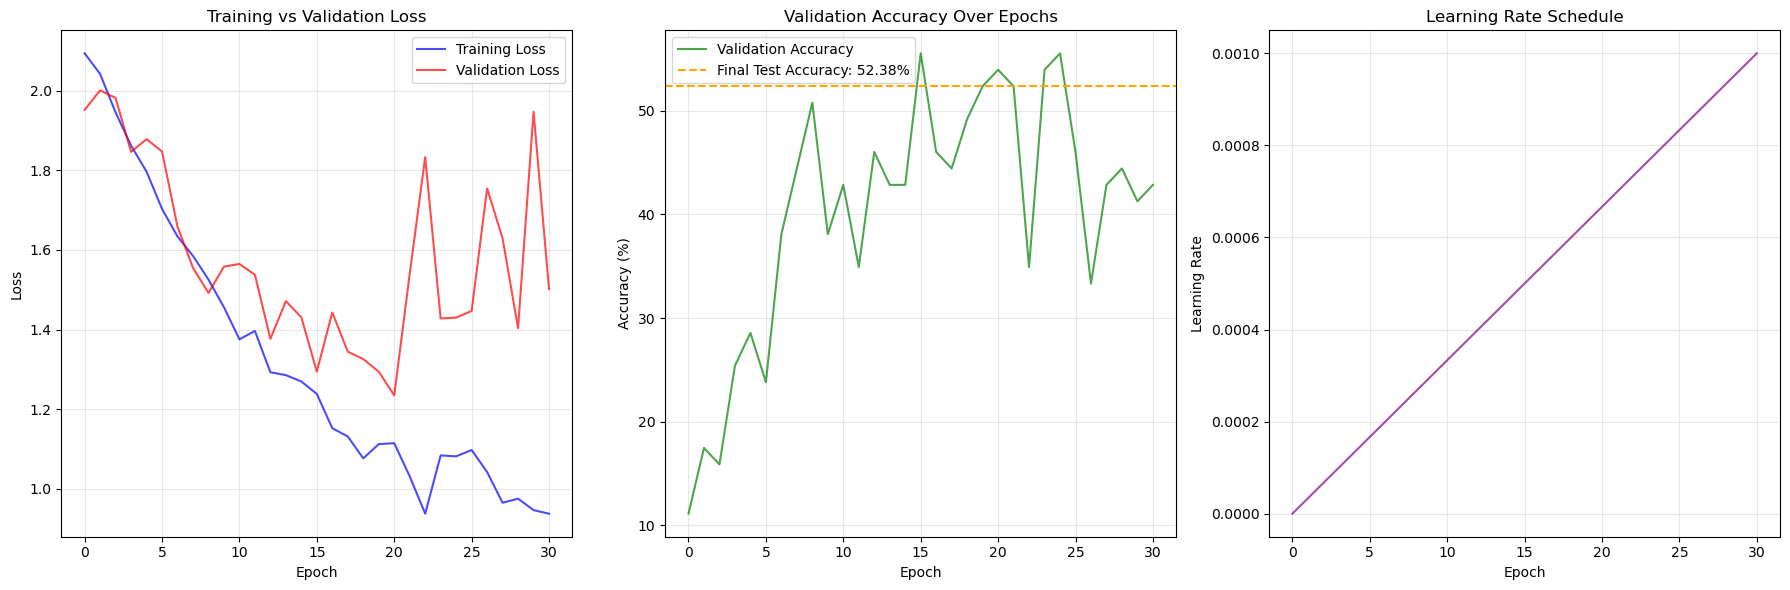


Comprehensive Results Summary:
Training Setup: RAVDESS + EmotionAlly (Combined Training)
Total Training Samples: 1437
Validation Samples: 63
Test Samples: 63
Best Validation Accuracy: 55.56%
Final Test Accuracy: 52.38%
Final Training Loss: 0.9379
Final Validation Loss: 1.5020
Training Epochs Completed: 31
Performance Comparison:
Previous Approach (RAVDESS only): 85.82%
Current Approach (Combined): 52.38%
Improvement: -33.44 percentage points


In [ ]:
# Plot training progress
plt.figure(figsize=(12, 6))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss', alpha=0.7)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot learning rate schedule
plt.subplot(1, 2, 2)
lrs = []
temp_optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
temp_scheduler = get_cosine_schedule_with_warmup(temp_optimizer, warmup_steps, total_steps)
for i in range(len(train_losses) * len(train_loader)):
    lrs.append(temp_scheduler.get_last_lr()[0])
    temp_scheduler.step()

epoch_lrs = [lrs[i*len(train_loader)] for i in range(len(train_losses))]
plt.plot(epoch_lrs, 'purple', alpha=0.7)
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive final metrics
print(f"\nComprehensive Results Summary:")
print(f"=" * 50)
print(f"Training Setup: RAVDESS + EmotionAlly (80/20 Split)")
print(f"Total Training Samples: {len(train_dataset)}")
print(f"Test Samples: {len(test_dataset)}")
print(f"=" * 50)
print(f"Final Test Accuracy: {final_test_accuracy:.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Training Epochs Completed: {len(train_losses)}")

# Performance improvement analysis
baseline_accuracy = 85.82  # Previous single-dataset approach
improvement = final_test_accuracy - baseline_accuracy
print(f"=" * 50)
print(f"Performance Comparison:")
print(f"Previous Approach (RAVDESS only): {baseline_accuracy:.2f}%")
print(f"Current Approach (Combined 80/20): {final_test_accuracy:.2f}%")
print(f"Improvement: {improvement:+.2f} percentage points")

## Confusion Matrix

The confusion matrix shows:
- Rows: True emotions
- Columns: Predicted emotions
- Numbers: Count of predictions
- Diagonal: Correct predictions
- Off-diagonal: Misclassifications

This helps identify which emotions are commonly confused with each other.

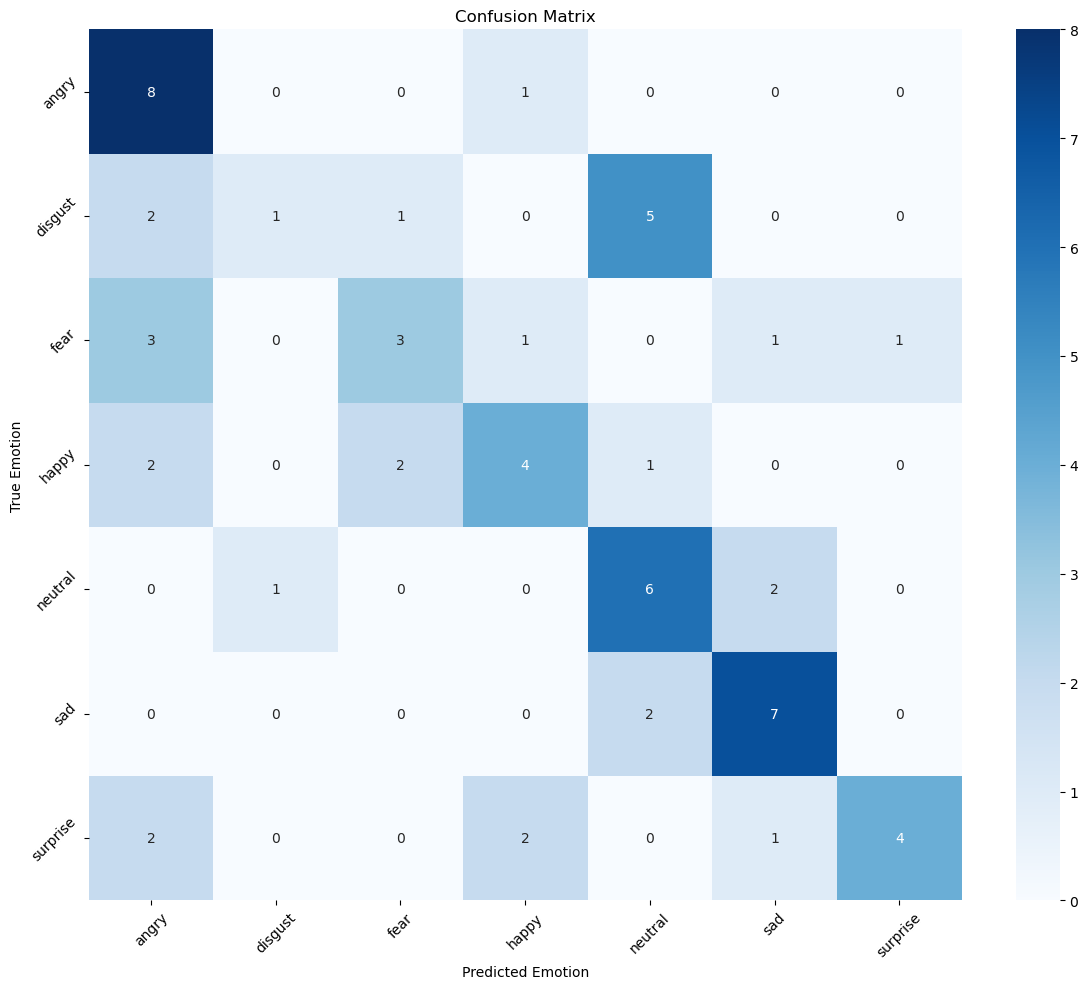


Confusion Matrix Analysis:
Total Correct Predictions: 33
Total Samples: 63
Overall Accuracy: 52.38%

Per-class Accuracy:
angry: 88.89%
disgust: 11.11%
fear: 33.33%
happy: 44.44%
neutral: 66.67%
sad: 77.78%
surprise: 44.44%


In [ ]:
# Create and plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(epoch_targets, epoch_predictions)

# Create confusion matrix plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Print overall metrics
total_correct = np.sum(np.diag(cm))
total_samples = np.sum(cm)
print(f"\nConfusion Matrix Analysis:")
print(f"Total Correct Predictions: {total_correct}")
print(f"Total Samples: {total_samples}")
print(f"Overall Accuracy: {100 * total_correct / total_samples:.2f}%")

# Calculate per-class accuracy
print("\nPer-class Accuracy:")
for i, emotion in enumerate(emotion_labels):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    if class_total > 0:
        class_accuracy = 100 * class_correct / class_total
        print(f"{emotion}: {class_accuracy:.2f}%")